Simulation Complete. Success:


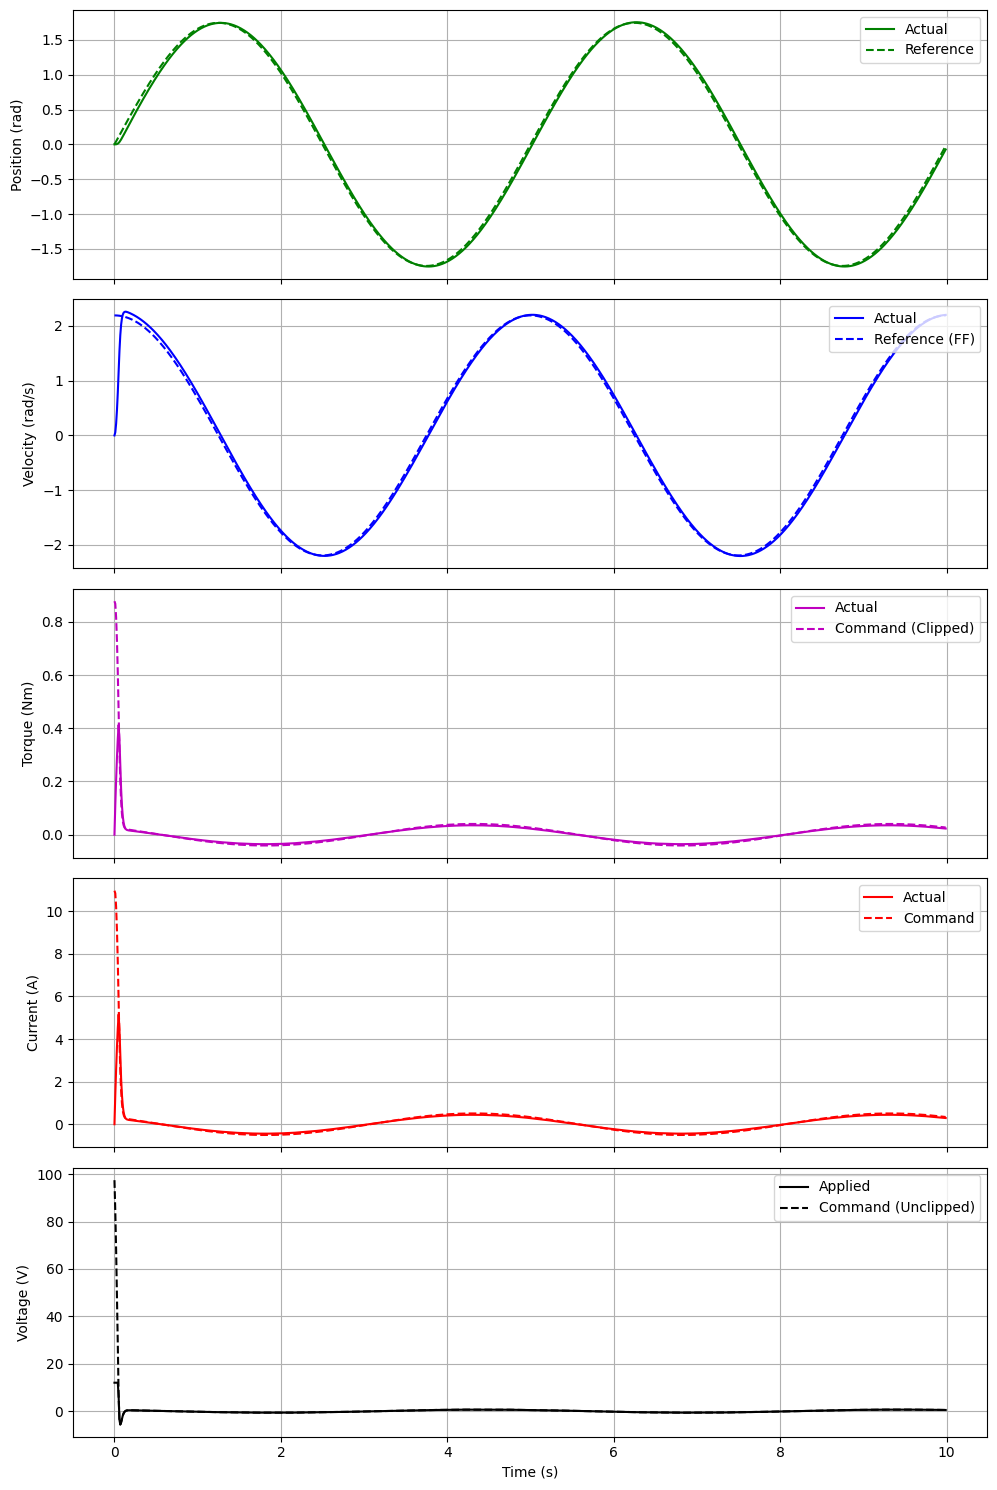

In [53]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.integrate as sci_int

Ra = 1.2
La = 0.08
Kt = 0.08
Kb = 0.08
Jm = 0.01
Bf = 0.01

V_max = 12 
T_max = 1.5
Omega_max = 4.71

Theta_amp = 100 * (np.pi / 180) #rad
Theta_freq = 0.2
Tload = 0

Omega_amp = Theta_amp * (2 * np.pi * Theta_freq)

x0 = [0, 0, 0]

startTime = 0
endTime = 10
dt = 0.01
t_eval = np.arange(startTime, endTime, dt)

Kp_position = 0.6
Kd_position = 1
 
Kp_velocity = 1
Kd_velocity = 0.4

Kp_current = 10
Kd_current = 0.01

def motor_plant(t, x):
    I = x[0]
    Theta = x[1]
    Omega = x[2]

    Theta_ref = Theta_amp * np.sin(2 * np.pi * Theta_freq * t)
    Omega_ref_ff = Theta_amp * 2 * np.pi * Theta_freq * np.cos(2 * np.pi * Theta_freq * t)
    
    error_theta = Theta_ref - Theta
    #derror_theta = Omega_ref_ff - Omega
    
    # Omega_cmd = (Kp_position * error_theta) + (Kd_position * derror_theta)

    error_Omega = Omega_ref_ff - Omega
    
    #domega_actual = (Kt * I - Bf * Omega - Tload) / Jm
    #derror_Omega = -domega_actual
    
    T_cmd = (Kp_position * error_theta) + (Kd_velocity * error_Omega)
    
    T_cmd = np.clip(T_cmd, -T_max, T_max)
    I_cmd = T_cmd / Kt

    error_current = I_cmd - I
    
    numerator = (Kp_current * error_current) + (Kd_current / La) * (Ra * I + Kb * Omega)
    denominator = 1 + (Kd_current / La)
    V_cmd = numerator / denominator

    V_app = np.clip(V_cmd, -V_max, V_max)
    
    dtheta = Omega 
    domega = (Kt * I - Bf * Omega - Tload) / Jm  
    dcurrent = (V_app - Ra * I - Kb * Omega) / La
    
    return [dcurrent, dtheta, domega]
    
solution = sci_int.solve_ivp(
    motor_plant,
    t_eval=t_eval,
    t_span=(startTime, endTime),
    y0=x0
)

def plot_pd_motor_results(solution):
    t = solution.t
    I = solution.y[0]
    Theta = solution.y[1]
    Omega = solution.y[2]

    Theta_ref = Theta_amp * np.sin(2 * np.pi * Theta_freq * t)
    Omega_ref_ff = Theta_amp * 2 * np.pi * Theta_freq * np.cos(2 * np.pi * Theta_freq * t)
    
    error_theta = Theta_ref - Theta
    error_Omega = Omega_ref_ff - Omega
    
    T_cmd = (Kp_position * error_theta) + (Kd_velocity * error_Omega)
    
    T_cmd_clipped = np.clip(T_cmd, -T_max, T_max)
    T_actual = Kt * I
    
    I_cmd = T_cmd_clipped / Kt
    
    error_current = I_cmd - I
    numerator = (Kp_current * error_current) + (Kd_current / La) * (Ra * I + Kb * Omega)
    denominator = 1 + (Kd_current / La)
    V_cmd = numerator / denominator
    V_app = np.clip(V_cmd, -V_max, V_max)

    fig, axs = plt.subplots(5, 1, figsize=(10, 15), sharex=True)
    
    axs[0].plot(t, Theta, color='g', label='Actual')
    axs[0].plot(t, Theta_ref, color='g', linestyle='--', label='Reference')
    axs[0].set_ylabel('Position (rad)')
    axs[0].legend(loc='upper right')
    axs[0].grid(True)
    
    axs[1].plot(t, Omega, color='b', label='Actual')
    axs[1].plot(t, Omega_ref_ff, color='b', linestyle='--', label='Reference (FF)')
    axs[1].set_ylabel('Velocity (rad/s)')
    axs[1].legend(loc='upper right')
    axs[1].grid(True)
    
    axs[2].plot(t, T_actual, color='m', label='Actual')
    axs[2].plot(t, T_cmd_clipped, color='m', linestyle='--', label='Command (Clipped)')
    axs[2].set_ylabel('Torque (Nm)')
    axs[2].legend(loc='upper right')
    axs[2].grid(True)
    
    axs[3].plot(t, I, color='r', label='Actual')
    axs[3].plot(t, I_cmd, color='r', linestyle='--', label='Command')
    axs[3].set_ylabel('Current (A)')
    axs[3].legend(loc='upper right')
    axs[3].grid(True)
    
    axs[4].plot(t, V_app, color='k', label='Applied')
    axs[4].plot(t, V_cmd, color='k', linestyle='--', label='Command (Unclipped)')
    axs[4].set_ylabel('Voltage (V)')
    axs[4].set_xlabel('Time (s)')
    axs[4].legend(loc='upper right')
    axs[4].grid(True)
    
    plt.tight_layout()
    plt.show()


print("Simulation Complete. Success:")
plot_pd_motor_results(solution)